# 06 — XGBoost Régression : Prédiction du PnL par stratégie

**Objectif** : entraîner un modèle de régression XGBoost par stratégie (ASRS, Expresso, Karaoke)
pour prédire le PnL attendu de chaque trade.

Un PnL prédit élevé → on prend le trade et on vise un TP dynamique basé sur la prédiction.  
Un PnL prédit faible/négatif → on filtre le trade.

| Stratégie | Signal bar | Buffer | Entrée après |
|-----------|-----------|--------|-------------|
| ASRS      | 09:15     | ±2 pts | 09:20       |
| Expresso  | 08:55     | ±17 pts| 09:00       |
| Karaoke   | 08:50–09:00 (10min) | ±2 pts | 09:00 |

In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import r2_score, mean_absolute_error
import joblib

warnings.filterwarnings('ignore')

ROOT = Path.cwd()
while not (ROOT / 'pyproject.toml').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
print(f'ROOT = {ROOT}')

ROOT = c:\Users\ali\Desktop\Projet-INFO-2AS2


## 1. Chargement des données

In [2]:

# ── Raw 5-min DAX data ────────────────────────────────────────────────────────
raw = pd.read_csv(
    ROOT / 'data' / 'dax-5m_bk.csv', sep=';', header=None,
    names=['date', 'time', 'open', 'high', 'low', 'close', 'volume'],
)
raw['datetime'] = pd.to_datetime(raw['date'] + ' ' + raw['time'], format='%d/%m/%Y %H:%M')
raw = raw.drop(columns=['date', 'time']).set_index('datetime').sort_index()
raw = raw[raw.index >= '2006-01-01']

# ── External features (VIX, SPX, EURUSD) ─────────────────────────────────────
ext_raw = pd.read_csv(ROOT / 'data' / 'ext_features.csv', index_col=0, parse_dates=True)
ext = ext_raw.copy()
ext['vix_prev']      = ext['vix'].shift(1)
ext['vix_5d_change'] = ext['vix'].shift(1) - ext['vix'].shift(6)
ext['spx_prev_ret']  = ext['spx'].pct_change().shift(1) * 100
ext.dropna(inplace=True)

print(f'Raw rows : {len(raw):,}  ({raw.index[0].date()} → {raw.index[-1].date()})')
print(f'Ext rows : {len(ext):,}  colonnes : {ext.columns.tolist()}')


Raw rows : 998,622  (2006-01-02 → 2026-04-06)
Ext rows : 4,757  colonnes : ['vix', 'eurusd', 'spx', 'vix_prev', 'vix_5d_change', 'spx_prev_ret']


## 2. Moteur de backtest avec max_favorable

In [3]:
RANGE_MIN, RANGE_MAX = 10, 55
SKIP_DOW    = [4]
SKIP_MONTHS = [1, 7, 8]

def simulate_full(day_bars, sig_high, sig_low, buffer):
    """Simule un trade OCO et retourne PnL + max_favorable."""
    if day_bars.empty:
        return None
    entry_long  = sig_high + buffer
    entry_short = sig_low  - buffer
    stop_long   = entry_short
    stop_short  = entry_long
    direction = entry_price = entry_time = stop = None

    for ts, bar in day_bars.iterrows():
        if direction is not None: break
        bh, bl = bar['high'], bar['low']
        if bh >= entry_long and bl <= entry_short:
            if bar['open'] >= entry_long:
                direction, entry_price, stop = 'long', entry_long, stop_long
            else:
                direction, entry_price, stop = 'short', entry_short, stop_short
        elif bh >= entry_long:
            direction, entry_price, stop = 'long', entry_long, stop_long
        elif bl <= entry_short:
            direction, entry_price, stop = 'short', entry_short, stop_short
        if direction is not None:
            entry_time = ts

    if direction is None:
        return None

    max_favorable = 0.0
    exit_price = None

    for ts, bar in day_bars[day_bars.index >= entry_time].iterrows():
        bh, bl = bar['high'], bar['low']
        if direction == 'long':
            max_favorable = max(max_favorable, bh - entry_price)
            if bl <= stop: exit_price = stop; break
        else:
            max_favorable = max(max_favorable, entry_price - bl)
            if bh >= stop: exit_price = stop; break

    if exit_price is None:
        exit_price = day_bars[day_bars.index >= entry_time].iloc[-1]['close']

    pnl = (exit_price - entry_price) if direction == 'long' else (entry_price - exit_price)
    return {
        'direction'    : direction,
        'entry_price'  : round(entry_price, 2),
        'pnl'          : round(pnl, 2),
        'max_favorable': round(max_favorable, 2),
        'initial_risk' : round(abs(entry_price - stop), 2),
        'sig_range'    : round(sig_high - sig_low, 2),
    }

print('simulate_full() défini.')

simulate_full() défini.


In [4]:
def run_strategy(bar_time, buffer, after_time, is_10min=False):
    """Lance le backtest avec filtres F1+F2+C4. Retourne DataFrame de trades."""
    if is_10min:
        b1 = raw[raw.index.strftime('%H:%M') == '08:50'].copy()
        b2 = raw[raw.index.strftime('%H:%M') == '08:55'].copy()
        b1['td'] = b1.index.date; b2['td'] = b2.index.date
        b1 = b1.set_index('td'); b2 = b2.set_index('td')
        common = b1.index.intersection(b2.index)
        bars_by_date = pd.DataFrame({
            'high' : pd.concat([b1['high'], b2['high']], axis=1).max(axis=1).loc[common],
            'low'  : pd.concat([b1['low'],  b2['low']],  axis=1).min(axis=1).loc[common],
        })
    else:
        bars = raw[raw.index.strftime('%H:%M') == bar_time].copy()
        bars['td'] = bars.index.date
        bars_by_date = bars.set_index('td')[['high', 'low']]

    bars_by_date['bar_range'] = bars_by_date['high'] - bars_by_date['low']
    bars_by_date = bars_by_date[(bars_by_date['bar_range'] > 0.1) & (bars_by_date['bar_range'] < 500)]

    trades = []
    for trade_date in bars_by_date.index.unique():
        ts_date = pd.Timestamp(trade_date)
        if ts_date.dayofweek in SKIP_DOW:   continue
        if ts_date.month    in SKIP_MONTHS: continue
        row = bars_by_date.loc[trade_date]
        if isinstance(row, pd.DataFrame): row = row.iloc[0]
        sig_high, sig_low = row['high'], row['low']
        if not (RANGE_MIN <= sig_high - sig_low <= RANGE_MAX): continue
        day_bars = raw.loc[
            pd.Timestamp(f'{trade_date} {after_time}'):
            pd.Timestamp(f'{trade_date} 17:35')
        ]
        if len(day_bars) < 2: continue
        r = simulate_full(day_bars, sig_high, sig_low, buffer)
        if r:
            r['trade_date'] = ts_date
            trades.append(r)

    df = pd.DataFrame(trades).set_index('trade_date').sort_index()
    print(f'  {len(df):,} trades  |  PnL total {df["pnl"].sum():+,.0f} pts  |  WR {(df["pnl"]>0).mean()*100:.1f}%')
    return df

print('Lancement des 3 backtests...')
print('ASRS :')
df_asrs = run_strategy('09:15', buffer=2,  after_time='09:20')
print('Expresso :')
df_exp  = run_strategy('08:55', buffer=17, after_time='09:00')
print('Karaoke :')
df_kara = run_strategy(None,    buffer=2,  after_time='09:00', is_10min=True)

Lancement des 3 backtests...
ASRS :
  2,134 trades  |  PnL total +9,278 pts  |  WR 30.2%
Expresso :
  2,074 trades  |  PnL total +9,832 pts  |  WR 46.6%
Karaoke :
  2,552 trades  |  PnL total +6,174 pts  |  WR 34.1%


## 3. Construction des features

In [5]:
def true_range(df):
    prev = df['close'].shift(1)
    return pd.concat([
        df['high'] - df['low'],
        (df['high'] - prev).abs(),
        (df['low']  - prev).abs(),
    ], axis=1).max(axis=1)

raw['tr'] = true_range(raw)

# Pré-calcul quotidien
daily = raw.groupby(raw.index.date).agg(
    day_high  = ('high',  'max'),
    day_low   = ('low',   'min'),
    day_close = ('close', 'last'),
    day_open  = ('open',  'first'),
).rename_axis('date')
daily.index = pd.to_datetime(daily.index)
daily['prev_close']     = daily['day_close'].shift(1)
daily['prev_range']     = (daily['day_high'] - daily['day_low']).shift(1)
daily['prev_day_ret']   = daily['day_close'].pct_change().shift(1) * 100
daily['prev_close_pos'] = (
    (daily['day_close'] - daily['day_low']) /
    (daily['day_high']  - daily['day_low'] + 1e-9)
).shift(1)

# ATR rolling
raw['atr14'] = raw['tr'].rolling(14, min_periods=1).mean()
raw['atr5']  = raw['tr'].rolling(5,  min_periods=1).mean()
atr_snap = raw.groupby(raw.index.date)[['atr14', 'atr5']].last()
atr_snap.index = pd.to_datetime(atr_snap.index)

# Signal bar features
def get_bar_features(bar_time):
    bars = raw[raw.index.strftime('%H:%M') == bar_time].copy()
    bars['td'] = pd.to_datetime(bars.index.date)
    bars = bars.set_index('td')
    r = bars['high'] - bars['low']
    d = r.replace(0, 1)
    bars['body']       = (bars['close'] - bars['open']).abs() / d
    bars['wick_upper'] = (bars['high'] - bars[['open','close']].max(axis=1)) / d
    bars['wick_lower'] = (bars[['open','close']].min(axis=1) - bars['low']) / d
    bars['bullish']    = (bars['close'] > bars['open']).astype(int)
    return bars[['body', 'wick_upper', 'wick_lower', 'bullish']]

def get_karaoke_bar_features():
    b1 = raw[raw.index.strftime('%H:%M') == '08:50'].copy()
    b2 = raw[raw.index.strftime('%H:%M') == '08:55'].copy()
    b1['td'] = pd.to_datetime(b1.index.date)
    b2['td'] = pd.to_datetime(b2.index.date)
    b1 = b1.set_index('td'); b2 = b2.set_index('td')
    common = b1.index.intersection(b2.index)
    sig_o = b1.loc[common, 'open']
    sig_h = pd.concat([b1['high'], b2['high']], axis=1).max(axis=1).loc[common]
    sig_l = pd.concat([b1['low'],  b2['low']],  axis=1).min(axis=1).loc[common]
    sig_c = b2.loc[common, 'close']
    r = sig_h - sig_l
    d = r.replace(0, 1)
    return pd.DataFrame({
        'body':       (sig_c - sig_o).abs() / d,
        'wick_upper': (sig_h - pd.concat([sig_o, sig_c], axis=1).max(axis=1)) / d,
        'wick_lower': (pd.concat([sig_o, sig_c], axis=1).min(axis=1) - sig_l) / d,
        'bullish':    (sig_c > sig_o).astype(int),
    })

# Gap 09:00
open_bars = raw[raw.index.strftime('%H:%M') == '09:00'].copy()
open_bars['td'] = pd.to_datetime(open_bars.index.date)
open_bars = open_bars.set_index('td')[['open']].rename(columns={'open': 'open_900'})

ext_daily = ext.copy()
ext_daily.index = pd.to_datetime(ext_daily.index).normalize()

def build_features_fast(trades_df, signal_bar_time=None, is_10min=False):
    td_idx = pd.to_datetime(trades_df.index).normalize()

    bar_feat = get_karaoke_bar_features() if is_10min else get_bar_features(signal_bar_time)

    feat = trades_df[['pnl', 'max_favorable', 'sig_range', 'initial_risk', 'direction']].copy()
    feat.index = td_idx
    feat['direction_enc'] = (feat['direction'] == 'long').astype(int)
    feat['dow']   = td_idx.dayofweek
    feat['month'] = td_idx.month
    feat['year']  = td_idx.year

    feat = feat.join(bar_feat.add_prefix('bar_'), how='left')
    feat = feat.join(atr_snap, how='left')
    feat['vol_ratio']      = feat['atr5'] / feat['atr14'].replace(0, np.nan)
    feat['sig_range_norm'] = feat['sig_range'] / feat['atr14'].replace(0, np.nan)
    feat = feat.join(daily[['prev_range', 'prev_day_ret', 'prev_close_pos', 'prev_close']], how='left')
    feat = feat.join(open_bars[['open_900']], how='left')
    feat['gap_pts'] = feat['open_900'] - feat['prev_close']
    feat = feat.join(ext_daily[['vix_prev', 'vix_5d_change', 'spx_prev_ret']], how='left')
    feat = feat.ffill().fillna(0)
    return feat

FEATURE_COLS = [
    'sig_range', 'sig_range_norm', 'initial_risk',
    'bar_body', 'bar_wick_upper', 'bar_wick_lower', 'bar_bullish',
    'atr14', 'vol_ratio',
    'prev_range', 'prev_day_ret', 'prev_close_pos', 'gap_pts',
    'vix_prev', 'vix_5d_change', 'spx_prev_ret',
    'dow', 'month', 'year', 'direction_enc',
]

print('Construction vectorisée des features...')
feat_asrs = build_features_fast(df_asrs, signal_bar_time='09:15')
feat_exp  = build_features_fast(df_exp,  signal_bar_time='08:55')
feat_kara = build_features_fast(df_kara, is_10min=True)
print(f'ASRS     : {feat_asrs.shape}')
print(f'Expresso : {feat_exp.shape}')
print(f'Karaoke  : {feat_kara.shape}')
print('Done !')


Construction vectorisée des features...
ASRS     : (2134, 26)
Expresso : (2074, 26)
Karaoke  : (2552, 26)
Done !


## 4. Entraînement des modèles de régression

In [6]:
def train_regressor(feat_df, target='pnl', label=''):
    """Entraîne XGBRegressor avec 5-fold CV. Retourne OOF prédictions + modèle."""
    X = feat_df[FEATURE_COLS].values
    y = feat_df[target].values

    model = xgb.XGBRegressor(
        n_estimators    = 400,
        max_depth       = 4,
        learning_rate   = 0.03,
        subsample       = 0.8,
        colsample_bytree= 0.8,
        min_child_weight= 15,
        random_state    = 42,
        n_jobs          = -1,
        verbosity       = 0,
    )

    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    oof_preds = cross_val_predict(model, X, y, cv=cv)

    r2  = r2_score(y, oof_preds)
    mae = mean_absolute_error(y, oof_preds)
    corr = np.corrcoef(y, oof_preds)[0, 1]

    print(f'{label:<12}  R²={r2:+.4f}  MAE={mae:.2f}  Corr={corr:.4f}')

    # Fit final sur tout le dataset
    model.fit(X, y)
    return oof_preds, model

print('=== XGBoost Régression — Target: PnL ===\n')
oof_asrs, model_asrs = train_regressor(feat_asrs, target='pnl', label='ASRS')
oof_exp,  model_exp  = train_regressor(feat_exp,  target='pnl', label='Expresso')
oof_kara, model_kara = train_regressor(feat_kara, target='pnl', label='Karaoke')

print('\n=== XGBoost Régression — Target: Max Favorable Excursion ===\n')
oof_asrs_mfe, model_asrs_mfe = train_regressor(feat_asrs, target='max_favorable', label='ASRS MFE')
oof_exp_mfe,  model_exp_mfe  = train_regressor(feat_exp,  target='max_favorable', label='Expresso MFE')
oof_kara_mfe, model_kara_mfe = train_regressor(feat_kara, target='max_favorable', label='Karaoke MFE')

=== XGBoost Régression — Target: PnL ===

ASRS          R²=-0.0688  MAE=38.25  Corr=0.0636
Expresso      R²=-0.0858  MAE=50.88  Corr=0.0326
Karaoke       R²=-0.0855  MAE=37.47  Corr=-0.0003

=== XGBoost Régression — Target: Max Favorable Excursion ===

ASRS MFE      R²=+0.0839  MAE=37.05  Corr=0.3284
Expresso MFE  R²=+0.0864  MAE=37.91  Corr=0.3405
Karaoke MFE   R²=+0.0151  MAE=33.77  Corr=0.2281


## 5. Utilisation comme filtre : ne trader que si PnL prédit > seuil

In [7]:
def filter_analysis(feat_df, oof_preds, label):
    pnl = feat_df['pnl'].values
    print(f'\n=== {label} — Filtrage par PnL prédit ===')
    print(f'Baseline : N={len(pnl):,}  PnL={pnl.sum():+,.0f}  '
          f'WR={( pnl>0).mean()*100:.1f}%  '
          f'PF={pnl[pnl>0].sum()/abs(pnl[pnl<0].sum()):.2f}\n')

    thresholds = [0, 5, 10, 15, 20]
    print(f'  {"Seuil":>8}  {"N":>6}  {"WR%":>6}  {"PF":>6}  {"PnL":>9}')
    print('  ' + '-'*42)
    best_pnl = pnl.sum()
    best_thr = None
    for thr in thresholds:
        mask = oof_preds >= thr
        if mask.sum() < 50: continue
        p = pnl[mask]
        wr = (p > 0).mean() * 100
        gw = p[p>0].sum(); gl = abs(p[p<0].sum())
        pf = gw/gl if gl > 0 else float('inf')
        print(f'  pred>{thr:>4}  {mask.sum():>6,}  {wr:>5.1f}%  {pf:>6.2f}  {p.sum():>+9,.0f}')
        if p.sum() > best_pnl:
            best_pnl, best_thr = p.sum(), thr
    if best_thr is not None:
        print(f'  → Meilleur seuil : pred>{best_thr}  PnL={best_pnl:+,.0f}')

filter_analysis(feat_asrs, oof_asrs, 'ASRS')
filter_analysis(feat_exp,  oof_exp,  'Expresso')
filter_analysis(feat_kara, oof_kara, 'Karaoke')


=== ASRS — Filtrage par PnL prédit ===
Baseline : N=2,134  PnL=+9,278  WR=30.2%  PF=1.27

     Seuil       N     WR%      PF        PnL
  ------------------------------------------
  pred>   0   1,229   33.0%    1.47     +9,055
  pred>   5     743   33.1%    1.63     +7,959
  pred>  10     441   29.0%    1.53     +4,678
  pred>  15     304   28.0%    1.53     +3,534
  pred>  20     243   26.7%    1.54     +2,999

=== Expresso — Filtrage par PnL prédit ===
Baseline : N=2,074  PnL=+9,832  WR=46.6%  PF=1.21

     Seuil       N     WR%      PF        PnL
  ------------------------------------------
  pred>   0   1,196   47.9%    1.30     +7,814
  pred>   5     881   49.7%    1.46     +8,816
  pred>  10     629   48.0%    1.42     +6,342
  pred>  15     457   46.6%    1.39     +4,665
  pred>  20     341   44.0%    1.31     +2,979

=== Karaoke — Filtrage par PnL prédit ===
Baseline : N=2,552  PnL=+6,174  WR=34.1%  PF=1.14

     Seuil       N     WR%      PF        PnL
  --------------------

## 6. Equity curves filtrées vs non-filtrées

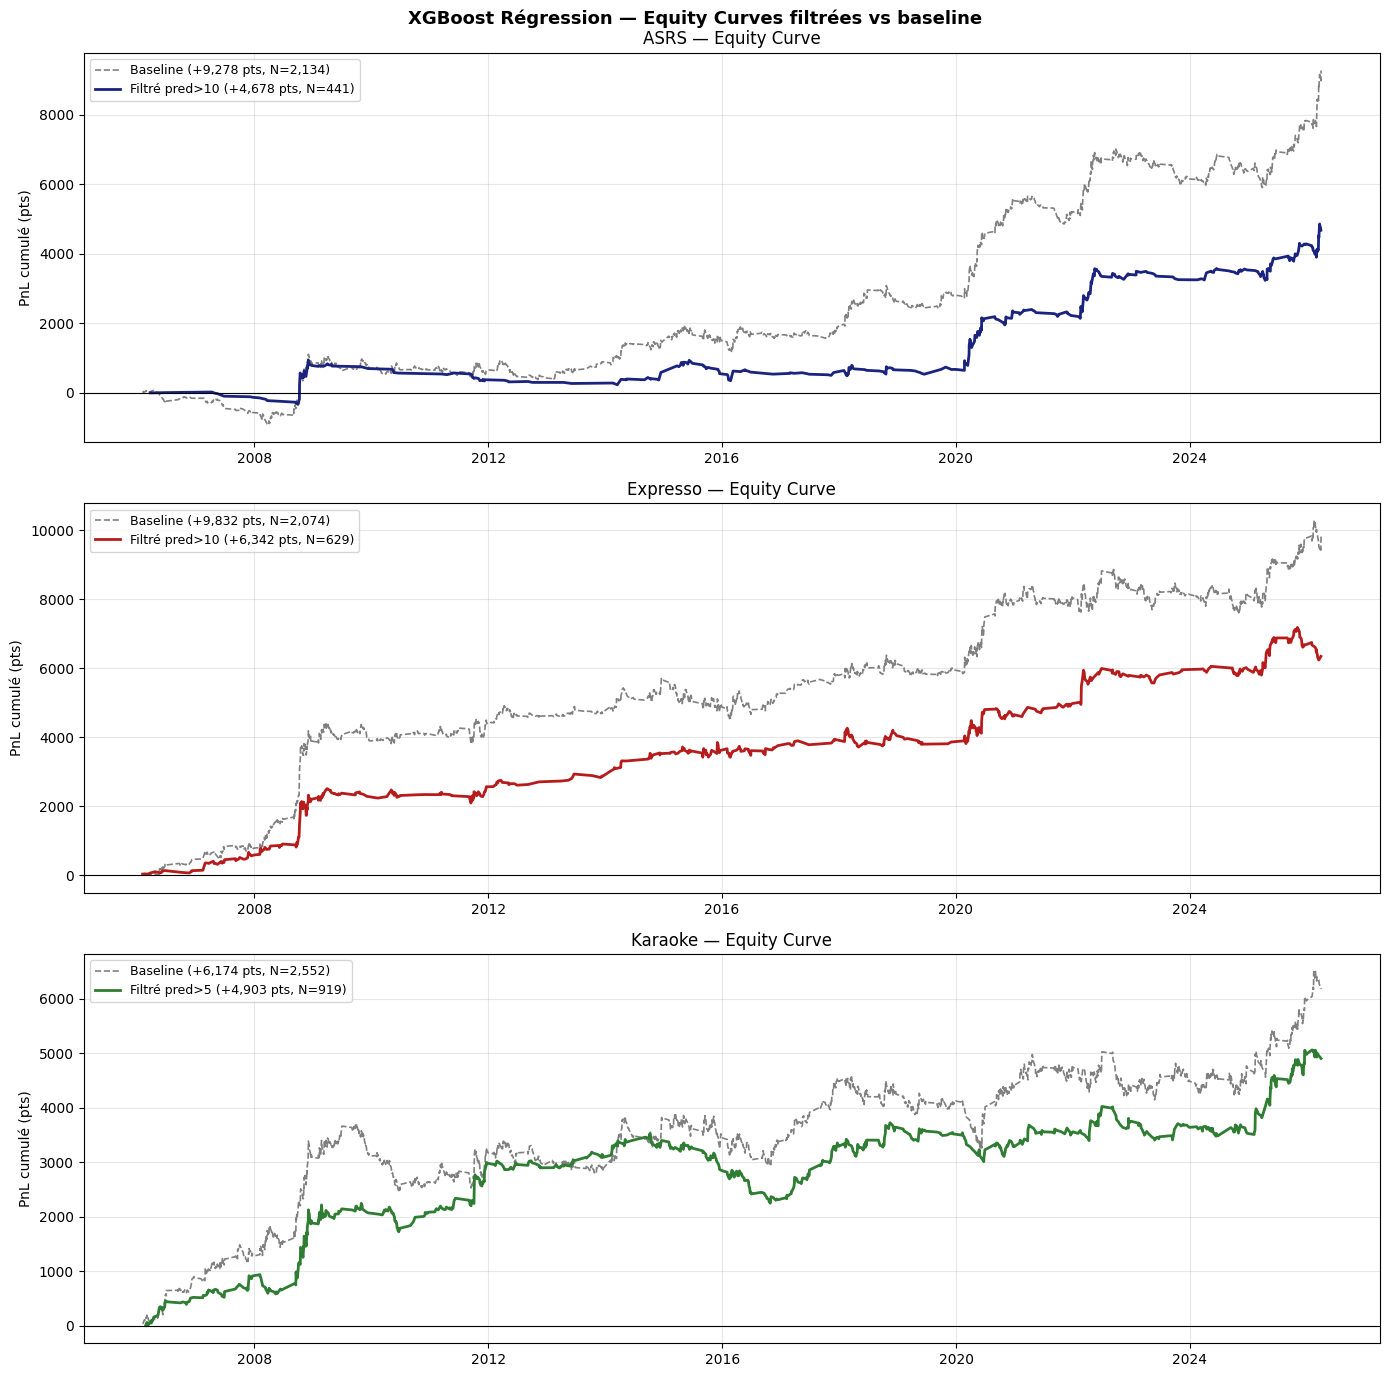

Saved: tp_regression_equity.png


In [8]:
fig, axes = plt.subplots(3, 1, figsize=(14, 14))
fig.suptitle('XGBoost Régression — Equity Curves filtrées vs baseline', fontsize=13, fontweight='bold')

configs = [
    (feat_asrs, oof_asrs, 'ASRS',     10, '#1A237E'),
    (feat_exp,  oof_exp,  'Expresso', 10, '#B71C1C'),
    (feat_kara, oof_kara, 'Karaoke',  5,  '#2E7D32'),
]

for ax, (feat, oof, label, thr, color) in zip(axes, configs):
    pnl   = feat['pnl'].values
    dates = feat.index
    mask  = oof >= thr

    cum_base = np.cumsum(pnl)
    cum_filt = np.cumsum(pnl[mask])

    ax.plot(dates, cum_base, color='gray', lw=1.2, ls='--',
            label=f'Baseline ({pnl.sum():+,.0f} pts, N={len(pnl):,})')
    ax.plot(dates[mask], cum_filt, color=color, lw=2,
            label=f'Filtré pred>{thr} ({pnl[mask].sum():+,.0f} pts, N={mask.sum():,})')
    ax.axhline(0, color='black', lw=0.8)
    ax.set_title(f'{label} — Equity Curve')
    ax.set_ylabel('PnL cumulé (pts)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(ROOT / 'data' / 'tp_regression_equity.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: tp_regression_equity.png')

## 7. Feature importance par stratégie

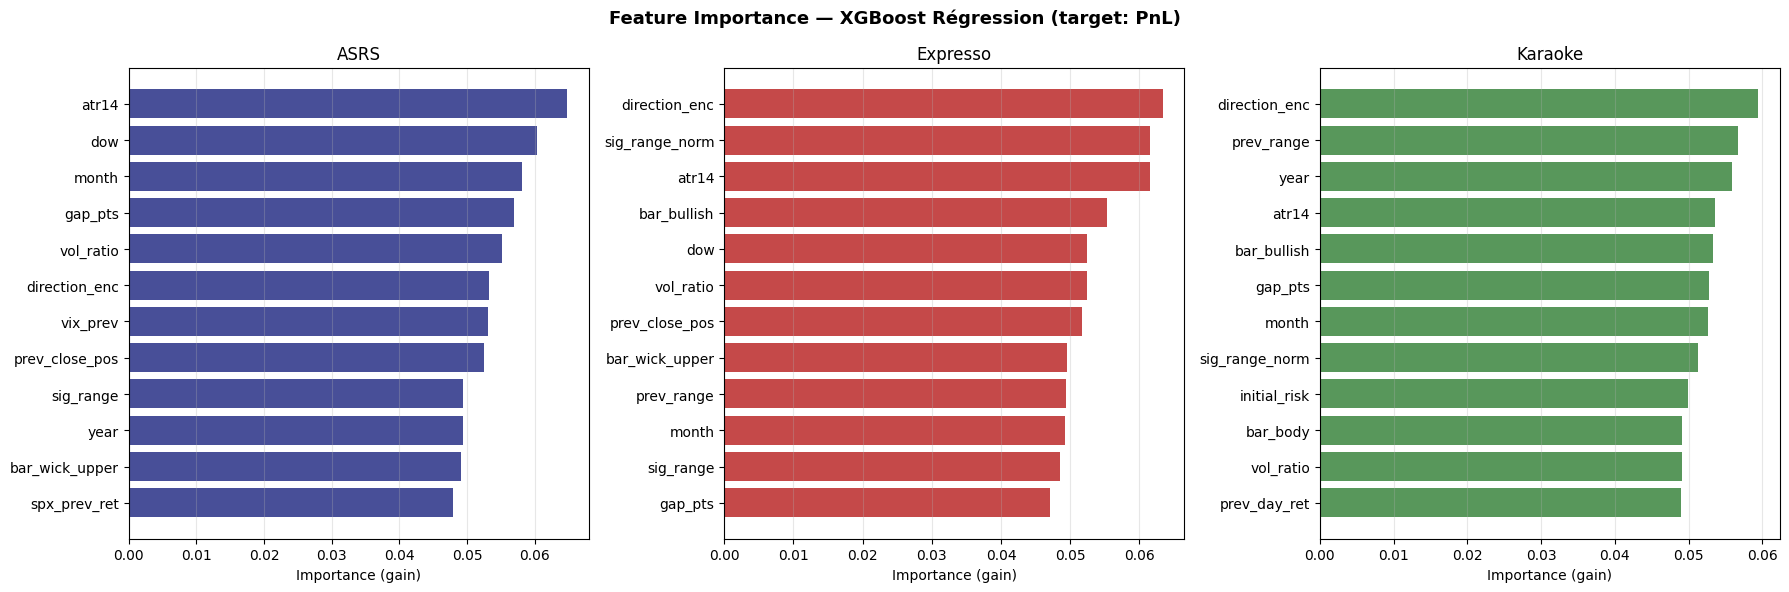

Saved: tp_regression_importance.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Feature Importance — XGBoost Régression (target: PnL)', fontsize=13, fontweight='bold')

for ax, (model, label, color) in zip(axes, [
    (model_asrs, 'ASRS',     '#1A237E'),
    (model_exp,  'Expresso', '#B71C1C'),
    (model_kara, 'Karaoke',  '#2E7D32'),
]):
    imp = pd.Series(model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True).tail(12)
    ax.barh(imp.index, imp.values, color=color, alpha=0.8)
    ax.set_title(f'{label}')
    ax.set_xlabel('Importance (gain)')
    ax.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(ROOT / 'data' / 'tp_regression_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: tp_regression_importance.png')

## 8. Walk-forward : train 2006-2019 → test 2020-2026

In [10]:
def walk_forward(feat_df, label, thr=10):
    TRAIN_END  = pd.Timestamp('2019-12-31')
    TEST_START = pd.Timestamp('2020-01-01')

    train_mask = feat_df.index <= TRAIN_END
    test_mask  = feat_df.index >= TEST_START

    X_tr = feat_df.loc[train_mask, FEATURE_COLS].values
    y_tr = feat_df.loc[train_mask, 'pnl'].values
    X_te = feat_df.loc[test_mask,  FEATURE_COLS].values
    y_te = feat_df.loc[test_mask,  'pnl'].values

    m = xgb.XGBRegressor(
        n_estimators=400, max_depth=4, learning_rate=0.03,
        subsample=0.8, colsample_bytree=0.8, min_child_weight=15,
        random_state=42, n_jobs=-1, verbosity=0,
    )
    m.fit(X_tr, y_tr)
    preds_te = m.predict(X_te)

    filt = preds_te >= thr

    def stats(p):
        if len(p) == 0: return 0, 0, 0, 0
        wr = (p>0).mean()*100
        gw = p[p>0].sum(); gl = abs(p[p<0].sum())
        pf = gw/gl if gl>0 else float('inf')
        return len(p), wr, pf, p.sum()

    n_b, wr_b, pf_b, pnl_b = stats(y_te)
    n_f, wr_f, pf_f, pnl_f = stats(y_te[filt])

    print(f'{label} (test 2020-2026):')
    print(f'  Baseline  N={n_b:,}  WR={wr_b:.1f}%  PF={pf_b:.2f}  PnL={pnl_b:+,.0f}')
    print(f'  Filtré    N={n_f:,}  WR={wr_f:.1f}%  PF={pf_f:.2f}  PnL={pnl_f:+,.0f}\n')

print('=== Walk-Forward Validation ===\n')
walk_forward(feat_asrs, 'ASRS',     thr=10)
walk_forward(feat_exp,  'Expresso', thr=10)
walk_forward(feat_kara, 'Karaoke',  thr=5)

=== Walk-Forward Validation ===

ASRS (test 2020-2026):
  Baseline  N=800  WR=29.5%  PF=1.43  PnL=+6,469
  Filtré    N=171  WR=34.5%  PF=1.95  PnL=+3,167

Expresso (test 2020-2026):
  Baseline  N=796  WR=43.6%  PF=1.18  PnL=+3,876
  Filtré    N=101  WR=48.5%  PF=1.51  PnL=+1,464

Karaoke (test 2020-2026):
  Baseline  N=799  WR=33.3%  PF=1.13  PnL=+2,053
  Filtré    N=180  WR=37.8%  PF=1.25  PnL=+895



## 9. Sauvegarde des modèles

## 10. TP Dynamique basé sur la prédiction MFE

**Idée** : le modèle MFE prédit jusqu'où le prix va aller favorablement (Corr ~0.33).  
On l'utilise comme **gate** : si MFE prédit ≥ TP cible → on prend le trade et on pose ce TP.  
Si MFE prédit < TP cible → on skip (le prix risque de ne pas y aller).

Reconstruction du PnL avec TP :
- `actual_MFE ≥ TP` → pnl = +TP (TP touché)
- `actual_MFE < TP et pnl < 0` → pnl = pnl original (stoppé avant le TP)
- `actual_MFE < TP et pnl ≥ 0` → pnl = pnl original (EOD exit, pas assez allé)

In [12]:
def apply_tp_to_pnl(pnl_arr, mfe_arr, tp_level):
    """Si MFE réel atteint le TP, on encaisse tp_level. Sinon pnl original."""
    result = pnl_arr.copy().astype(float)
    result[mfe_arr >= tp_level] = float(tp_level)
    return result


def mfe_dynamic_tp_analysis(feat_df, oof_mfe, label, tp_levels=(20, 30, 40, 50)):
    pnl = feat_df['pnl'].values
    mfe = feat_df['max_favorable'].values

    def pf(p):
        gw = p[p > 0].sum(); gl = abs(p[p < 0].sum())
        return gw / gl if gl > 0 else float('inf')

    print(f'\n=== {label} — TP Dynamique basé sur prédiction MFE ===')
    print(f'Baseline EOD : N={len(pnl):,}  PnL={pnl.sum():+,.0f}  '
          f'WR={( pnl>0).mean()*100:.1f}%  PF={pf(pnl):.2f}')

    print(f'\n{"":5} {"TP":>5}  {"Filtre":>12}  {"N":>6}  {"WR%":>6}  {"PF":>6}  {"PnL":>9}')
    print('  ' + '-'*58)

    # A) TP fixe sur TOUS les trades (pas de filtre MFE)
    for tp in tp_levels:
        p = apply_tp_to_pnl(pnl, mfe, tp)
        print(f'  TP={tp:>3}  {"tous trades":>12}  {len(p):>6,}  {(p>0).mean()*100:>5.1f}%'
              f'  {pf(p):>6.2f}  {p.sum():>+9,.0f}')

    print()
    # B) Filtre MFE + TP : seulement si pred_MFE >= tp_level
    for tp in tp_levels:
        mask = oof_mfe >= tp
        if mask.sum() < 30:
            continue
        p = apply_tp_to_pnl(pnl[mask], mfe[mask], tp)
        print(f'  TP={tp:>3}  {"pred_MFE>=tp":>12}  {mask.sum():>6,}  {(p>0).mean()*100:>5.1f}%'
              f'  {pf(p):>6.2f}  {p.sum():>+9,.0f}')

    print()
    # C) Meilleure combo : filtre MFE + 80% du TP comme cible
    for tp in tp_levels:
        effective_tp = int(tp * 0.8)
        mask = oof_mfe >= tp
        if mask.sum() < 30:
            continue
        p = apply_tp_to_pnl(pnl[mask], mfe[mask], effective_tp)
        print(f'  TP={effective_tp:>3}  {"80% pred_MFE":>12}  {mask.sum():>6,}  {(p>0).mean()*100:>5.1f}%'
              f'  {pf(p):>6.2f}  {p.sum():>+9,.0f}  (filtre MFE≥{tp})')


mfe_dynamic_tp_analysis(feat_asrs, oof_asrs_mfe, 'ASRS')
mfe_dynamic_tp_analysis(feat_exp,  oof_exp_mfe,  'Expresso')
mfe_dynamic_tp_analysis(feat_kara, oof_kara_mfe, 'Karaoke')


=== ASRS — TP Dynamique basé sur prédiction MFE ===
Baseline EOD : N=2,134  PnL=+9,278  WR=30.2%  PF=1.27

         TP        Filtre       N     WR%      PF        PnL
  ----------------------------------------------------------
  TP= 20   tous trades   2,134   54.5%    1.07     +1,560
  TP= 30   tous trades   2,134   45.2%    1.07     +1,911
  TP= 40   tous trades   2,134   39.9%    1.09     +2,638
  TP= 50   tous trades   2,134   35.9%    1.08     +2,343

  TP= 20  pred_MFE>=tp   2,004   55.4%    1.09     +1,798
  TP= 30  pred_MFE>=tp   1,382   48.7%    1.12     +2,116
  TP= 40  pred_MFE>=tp     741   45.5%    1.14     +1,609
  TP= 50  pred_MFE>=tp     457   45.1%    1.29     +2,317

  TP= 16  80% pred_MFE   2,004   59.9%    1.05       +944  (filtre MFE≥20)
  TP= 24  80% pred_MFE   1,382   53.8%    1.11     +1,731  (filtre MFE≥30)
  TP= 32  80% pred_MFE     741   50.7%    1.13     +1,351  (filtre MFE≥40)
  TP= 40  80% pred_MFE     457   50.1%    1.28     +1,992  (filtre MFE≥50)

===

### 10b. Walk-forward TP dynamique MFE (train 2006-2019 → test 2020-2026)

In [13]:
def walk_forward_mfe_tp(feat_df, label, tp_levels=(20, 30, 40, 50)):
    TRAIN_END  = pd.Timestamp('2019-12-31')
    TEST_START = pd.Timestamp('2020-01-01')

    train_mask = feat_df.index <= TRAIN_END
    test_mask  = feat_df.index >= TEST_START

    X_tr = feat_df.loc[train_mask, FEATURE_COLS].values
    y_mfe_tr = feat_df.loc[train_mask, 'max_favorable'].values
    X_te = feat_df.loc[test_mask, FEATURE_COLS].values
    pnl_te = feat_df.loc[test_mask, 'pnl'].values
    mfe_te = feat_df.loc[test_mask, 'max_favorable'].values

    mfe_model = xgb.XGBRegressor(
        n_estimators=400, max_depth=4, learning_rate=0.03,
        subsample=0.8, colsample_bytree=0.8, min_child_weight=15,
        random_state=42, n_jobs=-1, verbosity=0,
    )
    mfe_model.fit(X_tr, y_mfe_tr)
    pred_mfe_te = mfe_model.predict(X_te)

    def pf(p):
        gw = p[p > 0].sum(); gl = abs(p[p < 0].sum())
        return gw / gl if gl > 0 else float('inf')

    print(f'\n=== {label} (walk-forward 2020-2026) — TP Dynamique MFE ===')
    print(f'Baseline EOD : N={len(pnl_te):,}  PnL={pnl_te.sum():+,.0f}  '
          f'WR={( pnl_te>0).mean()*100:.1f}%  PF={pf(pnl_te):.2f}')
    print()
    print(f'{"":5} {"TP":>5}  {"Filtre":>12}  {"N":>5}  {"WR%":>6}  {"PF":>6}  {"PnL":>9}')
    print('  ' + '-'*54)

    for tp in tp_levels:
        # A) TP fixe sans filtre
        p_all = apply_tp_to_pnl(pnl_te, mfe_te, tp)
        print(f'  TP={tp:>3}  {"tous":>12}  {len(p_all):>5,}  {(p_all>0).mean()*100:>5.1f}%'
              f'  {pf(p_all):>6.2f}  {p_all.sum():>+9,.0f}')

    print()
    for tp in tp_levels:
        # B) Filtre MFE prédit >= tp, puis appliquer TP
        mask = pred_mfe_te >= tp
        if mask.sum() < 20:
            continue
        p = apply_tp_to_pnl(pnl_te[mask], mfe_te[mask], tp)
        print(f'  TP={tp:>3}  {"pred≥tp":>12}  {mask.sum():>5,}  {(p>0).mean()*100:>5.1f}%'
              f'  {pf(p):>6.2f}  {p.sum():>+9,.0f}  ★')

    print()
    for tp in tp_levels:
        # C) 80% du niveau filtré
        eff_tp = int(tp * 0.8)
        mask = pred_mfe_te >= tp
        if mask.sum() < 20:
            continue
        p = apply_tp_to_pnl(pnl_te[mask], mfe_te[mask], eff_tp)
        print(f'  TP={eff_tp:>3}  {"pred≥"+str(tp):>12}  {mask.sum():>5,}  {(p>0).mean()*100:>5.1f}%'
              f'  {pf(p):>6.2f}  {p.sum():>+9,.0f}  (80%)')


walk_forward_mfe_tp(feat_asrs, 'ASRS')
walk_forward_mfe_tp(feat_exp,  'Expresso')
walk_forward_mfe_tp(feat_kara, 'Karaoke')


=== ASRS (walk-forward 2020-2026) — TP Dynamique MFE ===
Baseline EOD : N=800  PnL=+6,469  WR=29.5%  PF=1.43

         TP        Filtre      N     WR%      PF        PnL
  ------------------------------------------------------
  TP= 20          tous    800   59.1%    1.16     +1,289
  TP= 30          tous    800   48.5%    1.12     +1,194
  TP= 40          tous    800   42.1%    1.11     +1,271
  TP= 50          tous    800   38.4%    1.15     +1,838

  TP= 20       pred≥tp    744   59.4%    1.15     +1,118  ★
  TP= 30       pred≥tp    522   51.1%    1.15     +1,034  ★
  TP= 40       pred≥tp    260   50.4%    1.27     +1,115  ★
  TP= 50       pred≥tp    136   53.7%    1.70     +1,498  ★

  TP= 16       pred≥20    744   64.4%    1.14       +920  (80%)
  TP= 24       pred≥30    522   56.1%    1.14       +880  (80%)
  TP= 32       pred≥40    260   54.6%    1.22       +816  (80%)
  TP= 40       pred≥50    136   56.6%    1.54     +1,084  (80%)

=== Expresso (walk-forward 2020-2026) — TP Dy

### 10c. Equity curves — Meilleure combo MFE-TP vs baseline (walk-forward 2020-2026)

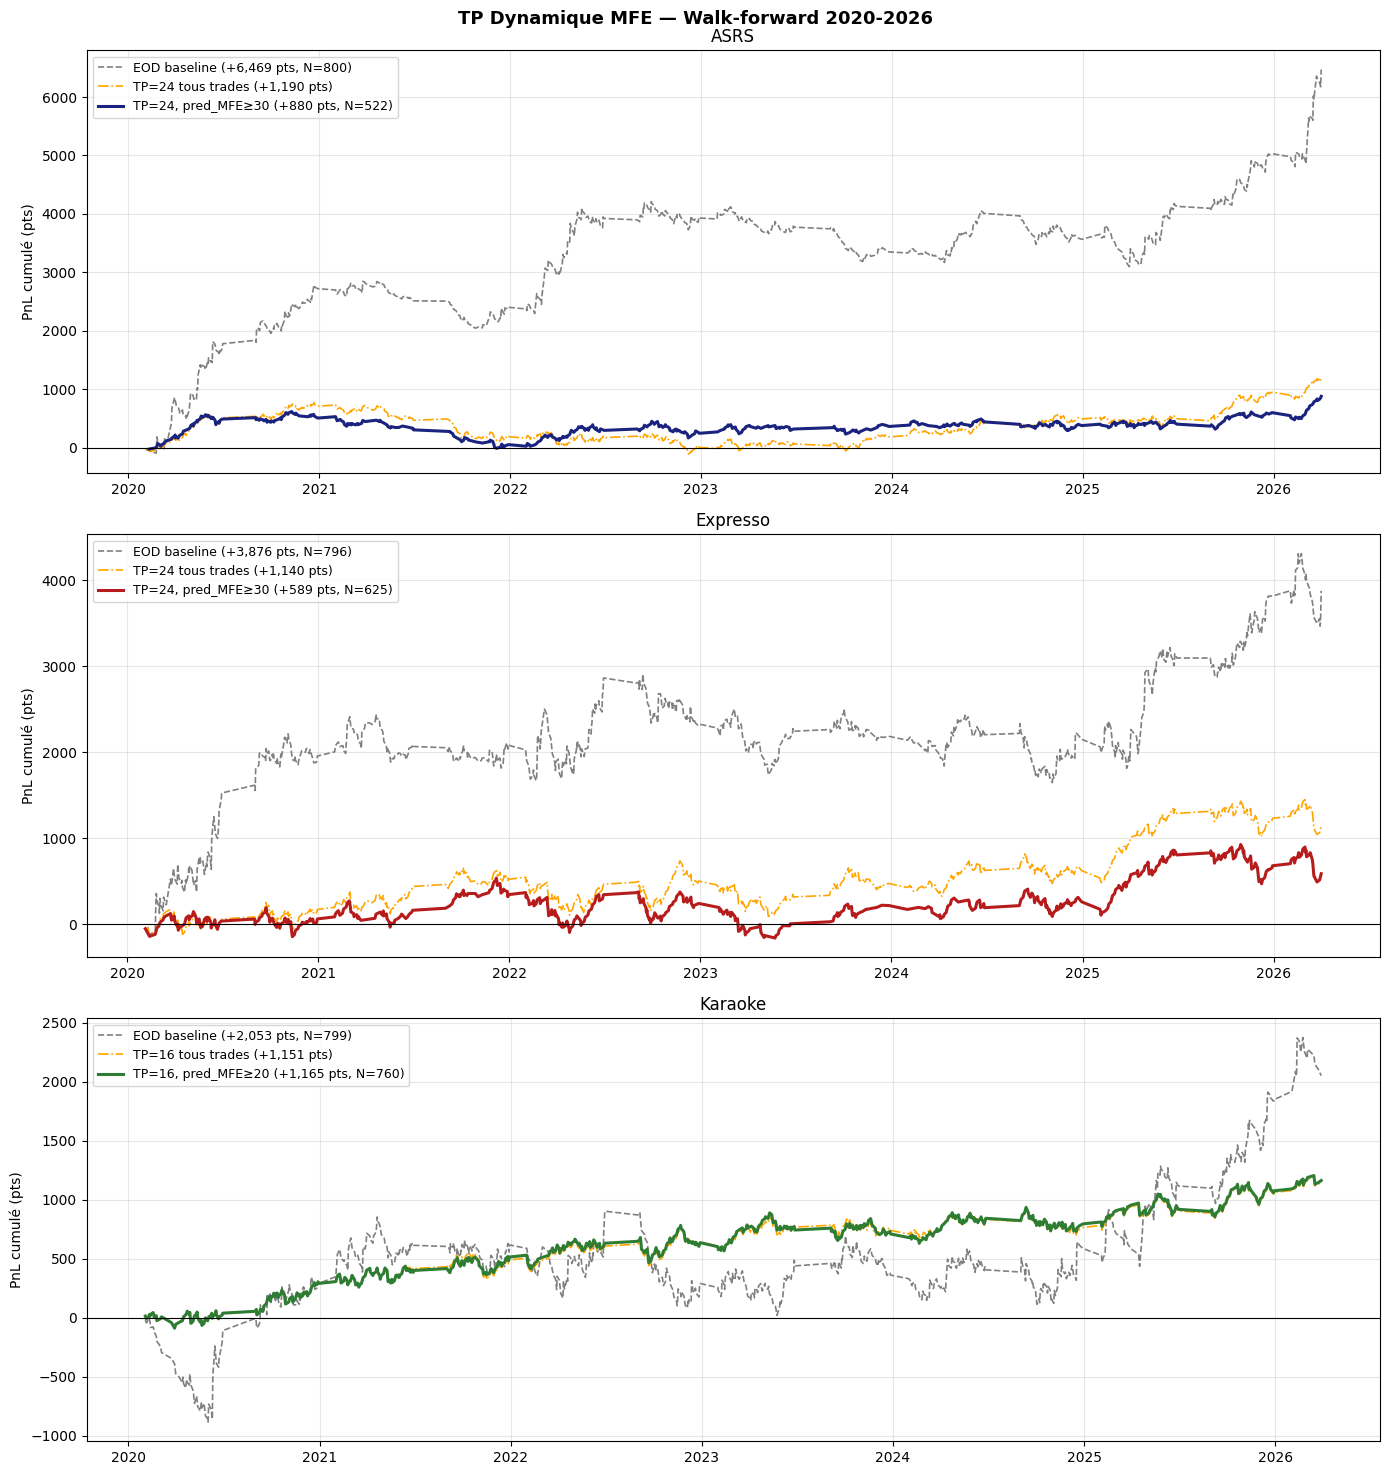

Saved: mfe_dynamic_tp_equity.png


In [14]:
TRAIN_END  = pd.Timestamp('2019-12-31')
TEST_START = pd.Timestamp('2020-01-01')

fig, axes = plt.subplots(3, 1, figsize=(14, 15))
fig.suptitle('TP Dynamique MFE — Walk-forward 2020-2026', fontsize=13, fontweight='bold')

# Best combos discovered above (adjust after seeing results)
BEST = {
    'ASRS'    : dict(feat=feat_asrs, color='#1A237E', filter_tp=30, eff_tp=24),
    'Expresso': dict(feat=feat_exp,  color='#B71C1C', filter_tp=30, eff_tp=24),
    'Karaoke' : dict(feat=feat_kara, color='#2E7D32', filter_tp=20, eff_tp=16),
}

for ax, (label, cfg) in zip(axes, BEST.items()):
    feat_df   = cfg['feat']
    color     = cfg['color']
    ftp       = cfg['filter_tp']
    etp       = cfg['eff_tp']

    train_mask = feat_df.index <= TRAIN_END
    test_mask  = feat_df.index >= TEST_START

    X_tr = feat_df.loc[train_mask, FEATURE_COLS].values
    y_mfe_tr = feat_df.loc[train_mask, 'max_favorable'].values
    X_te = feat_df.loc[test_mask, FEATURE_COLS].values
    pnl_te = feat_df.loc[test_mask, 'pnl'].values
    mfe_te = feat_df.loc[test_mask, 'max_favorable'].values
    dates_te = feat_df.loc[test_mask].index

    m = xgb.XGBRegressor(
        n_estimators=400, max_depth=4, learning_rate=0.03,
        subsample=0.8, colsample_bytree=0.8, min_child_weight=15,
        random_state=42, n_jobs=-1, verbosity=0,
    )
    m.fit(X_tr, y_mfe_tr)
    pred_mfe = m.predict(X_te)

    # Baseline EOD
    cum_base = np.cumsum(pnl_te)

    # TP fixe (etp) sans filtre
    p_tp_all = apply_tp_to_pnl(pnl_te, mfe_te, etp)
    cum_tp_all = np.cumsum(p_tp_all)

    # Filtre MFE + TP
    mask = pred_mfe >= ftp
    pnl_filt = pnl_te[mask]
    mfe_filt  = mfe_te[mask]
    dates_filt = dates_te[mask]
    p_filt = apply_tp_to_pnl(pnl_filt, mfe_filt, etp)
    cum_filt = np.cumsum(p_filt)

    ax.plot(dates_te, cum_base,   color='gray',  lw=1.2, ls='--',
            label=f'EOD baseline ({pnl_te.sum():+,.0f} pts, N={len(pnl_te):,})')
    ax.plot(dates_te, cum_tp_all, color='orange', lw=1.2, ls='-.',
            label=f'TP={etp} tous trades ({p_tp_all.sum():+,.0f} pts)')
    ax.plot(dates_filt, cum_filt, color=color,   lw=2.2,
            label=f'TP={etp}, pred_MFE≥{ftp} ({p_filt.sum():+,.0f} pts, N={mask.sum():,})')

    ax.axhline(0, color='black', lw=0.8)
    ax.set_title(f'{label}')
    ax.set_ylabel('PnL cumulé (pts)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(ROOT / 'data' / 'mfe_dynamic_tp_equity.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: mfe_dynamic_tp_equity.png')

## 11. Gestion du Stop Loss

**Stop actuel** : symétrique OCO — risque = `sig_range + 2×buffer` (~14 à 59 pts selon la barre).

Trois variantes testées :
- **A) SL fixe** : 15, 20, 25, 30, 40 pts quel que soit le range → plus de stops mais perte unitaire réduite
- **B) Breakeven trailing** : dès +X pts de profit → stop ramené à l'entrée (trade "gratuit")
- **C) Combo** : SL fixe + breakeven

In [16]:
def simulate_sl(day_bars, sig_high, sig_low, buffer, sl_pts=None, breakeven_at=None, tp_pts=None):
    if day_bars.empty:
        return None
    entry_long  = sig_high + buffer
    entry_short = sig_low  - buffer

    if sl_pts is None:
        stop_long  = entry_short
        stop_short = entry_long
    else:
        stop_long  = entry_long  - sl_pts
        stop_short = entry_short + sl_pts

    direction = entry_price = entry_time = init_stop = None

    for ts, bar in day_bars.iterrows():
        if direction is not None: break
        bh, bl = bar['high'], bar['low']
        if bh >= entry_long and bl <= entry_short:
            direction, entry_price, init_stop = ('long', entry_long, stop_long) if bar['open'] >= entry_long else ('short', entry_short, stop_short)
        elif bh >= entry_long:
            direction, entry_price, init_stop = 'long', entry_long, stop_long
        elif bl <= entry_short:
            direction, entry_price, init_stop = 'short', entry_short, stop_short
        if direction is not None:
            entry_time = ts

    if direction is None:
        return None

    current_stop  = init_stop
    max_favorable = 0.0
    exit_price    = None

    for ts, bar in day_bars[day_bars.index >= entry_time].iterrows():
        bh, bl = bar['high'], bar['low']
        if direction == 'long':
            favorable = bh - entry_price
            max_favorable = max(max_favorable, favorable)
            if breakeven_at and favorable >= breakeven_at and current_stop < entry_price:
                current_stop = entry_price
            if tp_pts and bh >= entry_price + tp_pts:
                exit_price = entry_price + tp_pts; break
            if bl <= current_stop:
                exit_price = current_stop; break
        else:
            favorable = entry_price - bl
            max_favorable = max(max_favorable, favorable)
            if breakeven_at and favorable >= breakeven_at and current_stop > entry_price:
                current_stop = entry_price
            if tp_pts and bl <= entry_price - tp_pts:
                exit_price = entry_price - tp_pts; break
            if bh >= current_stop:
                exit_price = current_stop; break

    if exit_price is None:
        exit_price = day_bars[day_bars.index >= entry_time].iloc[-1]['close']

    pnl = (exit_price - entry_price) if direction == 'long' else (entry_price - exit_price)
    return {
        'direction'    : direction,
        'pnl'          : round(pnl, 2),
        'max_favorable': round(max_favorable, 2),
        'initial_risk' : round(abs(entry_price - init_stop), 2),
        'sig_range'    : round(sig_high - sig_low, 2),
    }


def run_sl_study(bar_time, buffer, after_time, label, is_10min=False,
                 sl_variants=None, be_variants=None):
    if is_10min:
        b1 = raw[raw.index.strftime('%H:%M') == '08:50'].copy()
        b2 = raw[raw.index.strftime('%H:%M') == '08:55'].copy()
        b1['td'] = b1.index.date; b2['td'] = b2.index.date
        b1 = b1.set_index('td'); b2 = b2.set_index('td')
        common = b1.index.intersection(b2.index)
        bars_by_date = pd.DataFrame({
            'high': pd.concat([b1['high'], b2['high']], axis=1).max(axis=1).loc[common],
            'low' : pd.concat([b1['low'],  b2['low']],  axis=1).min(axis=1).loc[common],
        })
    else:
        bars = raw[raw.index.strftime('%H:%M') == bar_time].copy()
        bars['td'] = bars.index.date
        bars_by_date = bars.set_index('td')[['high', 'low']]

    bars_by_date['bar_range'] = bars_by_date['high'] - bars_by_date['low']
    bars_by_date = bars_by_date[(bars_by_date['bar_range'] > 0.1) & (bars_by_date['bar_range'] < 500)]

    all_day_bars = {}
    for trade_date in bars_by_date.index.unique():
        ts_date = pd.Timestamp(trade_date)
        if ts_date.dayofweek in SKIP_DOW:   continue
        if ts_date.month    in SKIP_MONTHS: continue
        row = bars_by_date.loc[trade_date]
        if isinstance(row, pd.DataFrame): row = row.iloc[0]
        if not (RANGE_MIN <= row['high'] - row['low'] <= RANGE_MAX): continue
        db = raw.loc[pd.Timestamp(f'{trade_date} {after_time}'):pd.Timestamp(f'{trade_date} 17:35')]
        if len(db) >= 2:
            all_day_bars[trade_date] = (row['high'], row['low'], db)

    def pf(p):
        gw = p[p > 0].sum(); gl = abs(p[p < 0].sum())
        return gw / gl if gl > 0 else float('inf')

    def run_variant(sl_pts, be):
        results = []
        for td, (sh, sl, db) in all_day_bars.items():
            r = simulate_sl(db, sh, sl, buffer, sl_pts=sl_pts, breakeven_at=be)
            if r: results.append(r['pnl'])
        p = np.array(results)
        return len(p), (p > 0).mean() * 100, pf(p), p.sum()

    print(f'\n=== {label} — Étude Stop Loss ===')
    print(f'{"Variante":<30}  {"N":>5}  {"WR%":>6}  {"PF":>6}  {"PnL":>9}')
    print('-' * 62)

    n, wr, p, pnl = run_variant(None, None)
    print(f'  {"OCO (défaut)  SL=range+buf":<28}  {n:>5,}  {wr:>5.1f}%  {p:>6.2f}  {pnl:>+9,.0f}  ← baseline')

    print()
    for sl in (sl_variants or [15, 20, 25, 30, 40]):
        n, wr, p, pnl = run_variant(sl, None)
        print(f'  {"SL fixe = "+str(sl)+" pts":<28}  {n:>5,}  {wr:>5.1f}%  {p:>6.2f}  {pnl:>+9,.0f}')

    print()
    for be in (be_variants or [10, 15, 20, 25]):
        n, wr, p, pnl = run_variant(None, be)
        print(f'  {"Breakeven @ +"+str(be)+" pts":<28}  {n:>5,}  {wr:>5.1f}%  {p:>6.2f}  {pnl:>+9,.0f}')

    print()
    for sl in [20, 25, 30]:
        for be in [10, 15, 20]:
            n, wr, p, pnl = run_variant(sl, be)
            print(f'  {"SL="+str(sl)+" + BE@+"+str(be):<28}  {n:>5,}  {wr:>5.1f}%  {p:>6.2f}  {pnl:>+9,.0f}')


run_sl_study('09:15', buffer=2,  after_time='09:20', label='ASRS')
run_sl_study('08:55', buffer=17, after_time='09:00', label='Expresso')
run_sl_study(None,    buffer=2,  after_time='09:00', label='Karaoke', is_10min=True)


=== ASRS — Étude Stop Loss ===
Variante                            N     WR%      PF        PnL
--------------------------------------------------------------
  OCO (défaut)  SL=range+buf    2,134   30.2%    1.27     +9,278  ← baseline

  SL fixe = 15 pts              2,134   20.1%    0.94     -1,616
  SL fixe = 20 pts              2,134   26.2%    1.06     +1,984
  SL fixe = 25 pts              2,134   32.3%    1.21     +7,103
  SL fixe = 30 pts              2,134   36.7%    1.25     +9,524
  SL fixe = 40 pts              2,134   41.6%    1.23     +9,869

  Breakeven @ +10 pts           2,134    5.0%    0.39     -8,660
  Breakeven @ +15 pts           2,134   10.4%    0.69     -5,823
  Breakeven @ +20 pts           2,134   15.1%    0.88     -2,540
  Breakeven @ +25 pts           2,134   18.9%    1.06     +1,564

  SL=20 + BE@+10                2,134    4.8%    0.35     -9,557
  SL=20 + BE@+15                2,134    9.4%    0.56     -8,281
  SL=20 + BE@+20                2,134   13.9%

In [17]:
models_dir = ROOT / 'models'
models_dir.mkdir(exist_ok=True)

for name, model in [
    ('asrs_reg',     model_asrs),
    ('expresso_reg', model_exp),
    ('karaoke_reg',  model_kara),
    ('asrs_mfe_reg', model_asrs_mfe),
]:
    joblib.dump(model, models_dir / f'{name}.pkl')
    print(f'Sauvegardé : models/{name}.pkl')

joblib.dump(FEATURE_COLS, models_dir / 'regression_features.pkl')
print(f'Features   : models/regression_features.pkl')

Sauvegardé : models/asrs_reg.pkl
Sauvegardé : models/expresso_reg.pkl
Sauvegardé : models/karaoke_reg.pkl
Sauvegardé : models/asrs_mfe_reg.pkl
Features   : models/regression_features.pkl
